M4: mu ~ N(0.1, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20, N=100, S=2D

In [15]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

In [16]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [17]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=100
mu_prior_mean=0.1
mu_prior_std=1
likelihood_std=1

In [18]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [19]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [20]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=2*num_dims, base_distribution="normal"
)

inference_net = bf.networks.CouplingFlow(depth=8,
                                         subnet_kwargs={"widths":(256,256,256),
                                                        "norm": "layer",},
                                                        )

In [21]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [22]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - loss: 17.5094 - loss/inference_loss: 17.2024 - loss/summary_loss: 0.3070
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - loss: 12.6664 - loss/inference_loss: 12.3392 - loss/summary_loss: 0.3272
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - loss: 9.0675 - loss/inference_loss: 8.7445 - loss/summary_loss: 0.3231 
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - loss: 6.4328 - loss/inference_loss: 6.0842 - loss/summary_loss: 0.3485
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - loss: 4.0291 - loss/inference_loss: 3.6853 - loss/summary_loss: 0.3437
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - loss: 1.7518 - loss/inference_loss: 1.3964 - loss/summary_loss: 0.3554
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - loss: -0.1744 - loss/inference_loss: -0.5373 - loss/summary_loss: 0.3629
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - loss: -1.5446 - loss/inference_l

INFO:bayesflow:Training completed in 29.30 minutes.


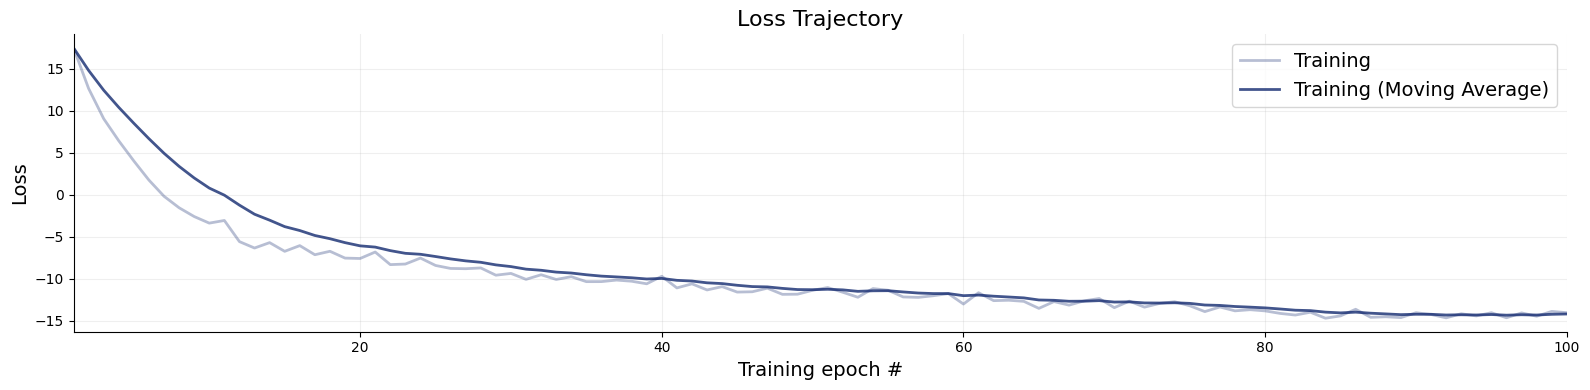

In [23]:
f=bf.diagnostics.plots.loss(history)

In [24]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 7.47 seconds.


dict_keys(['mu'])

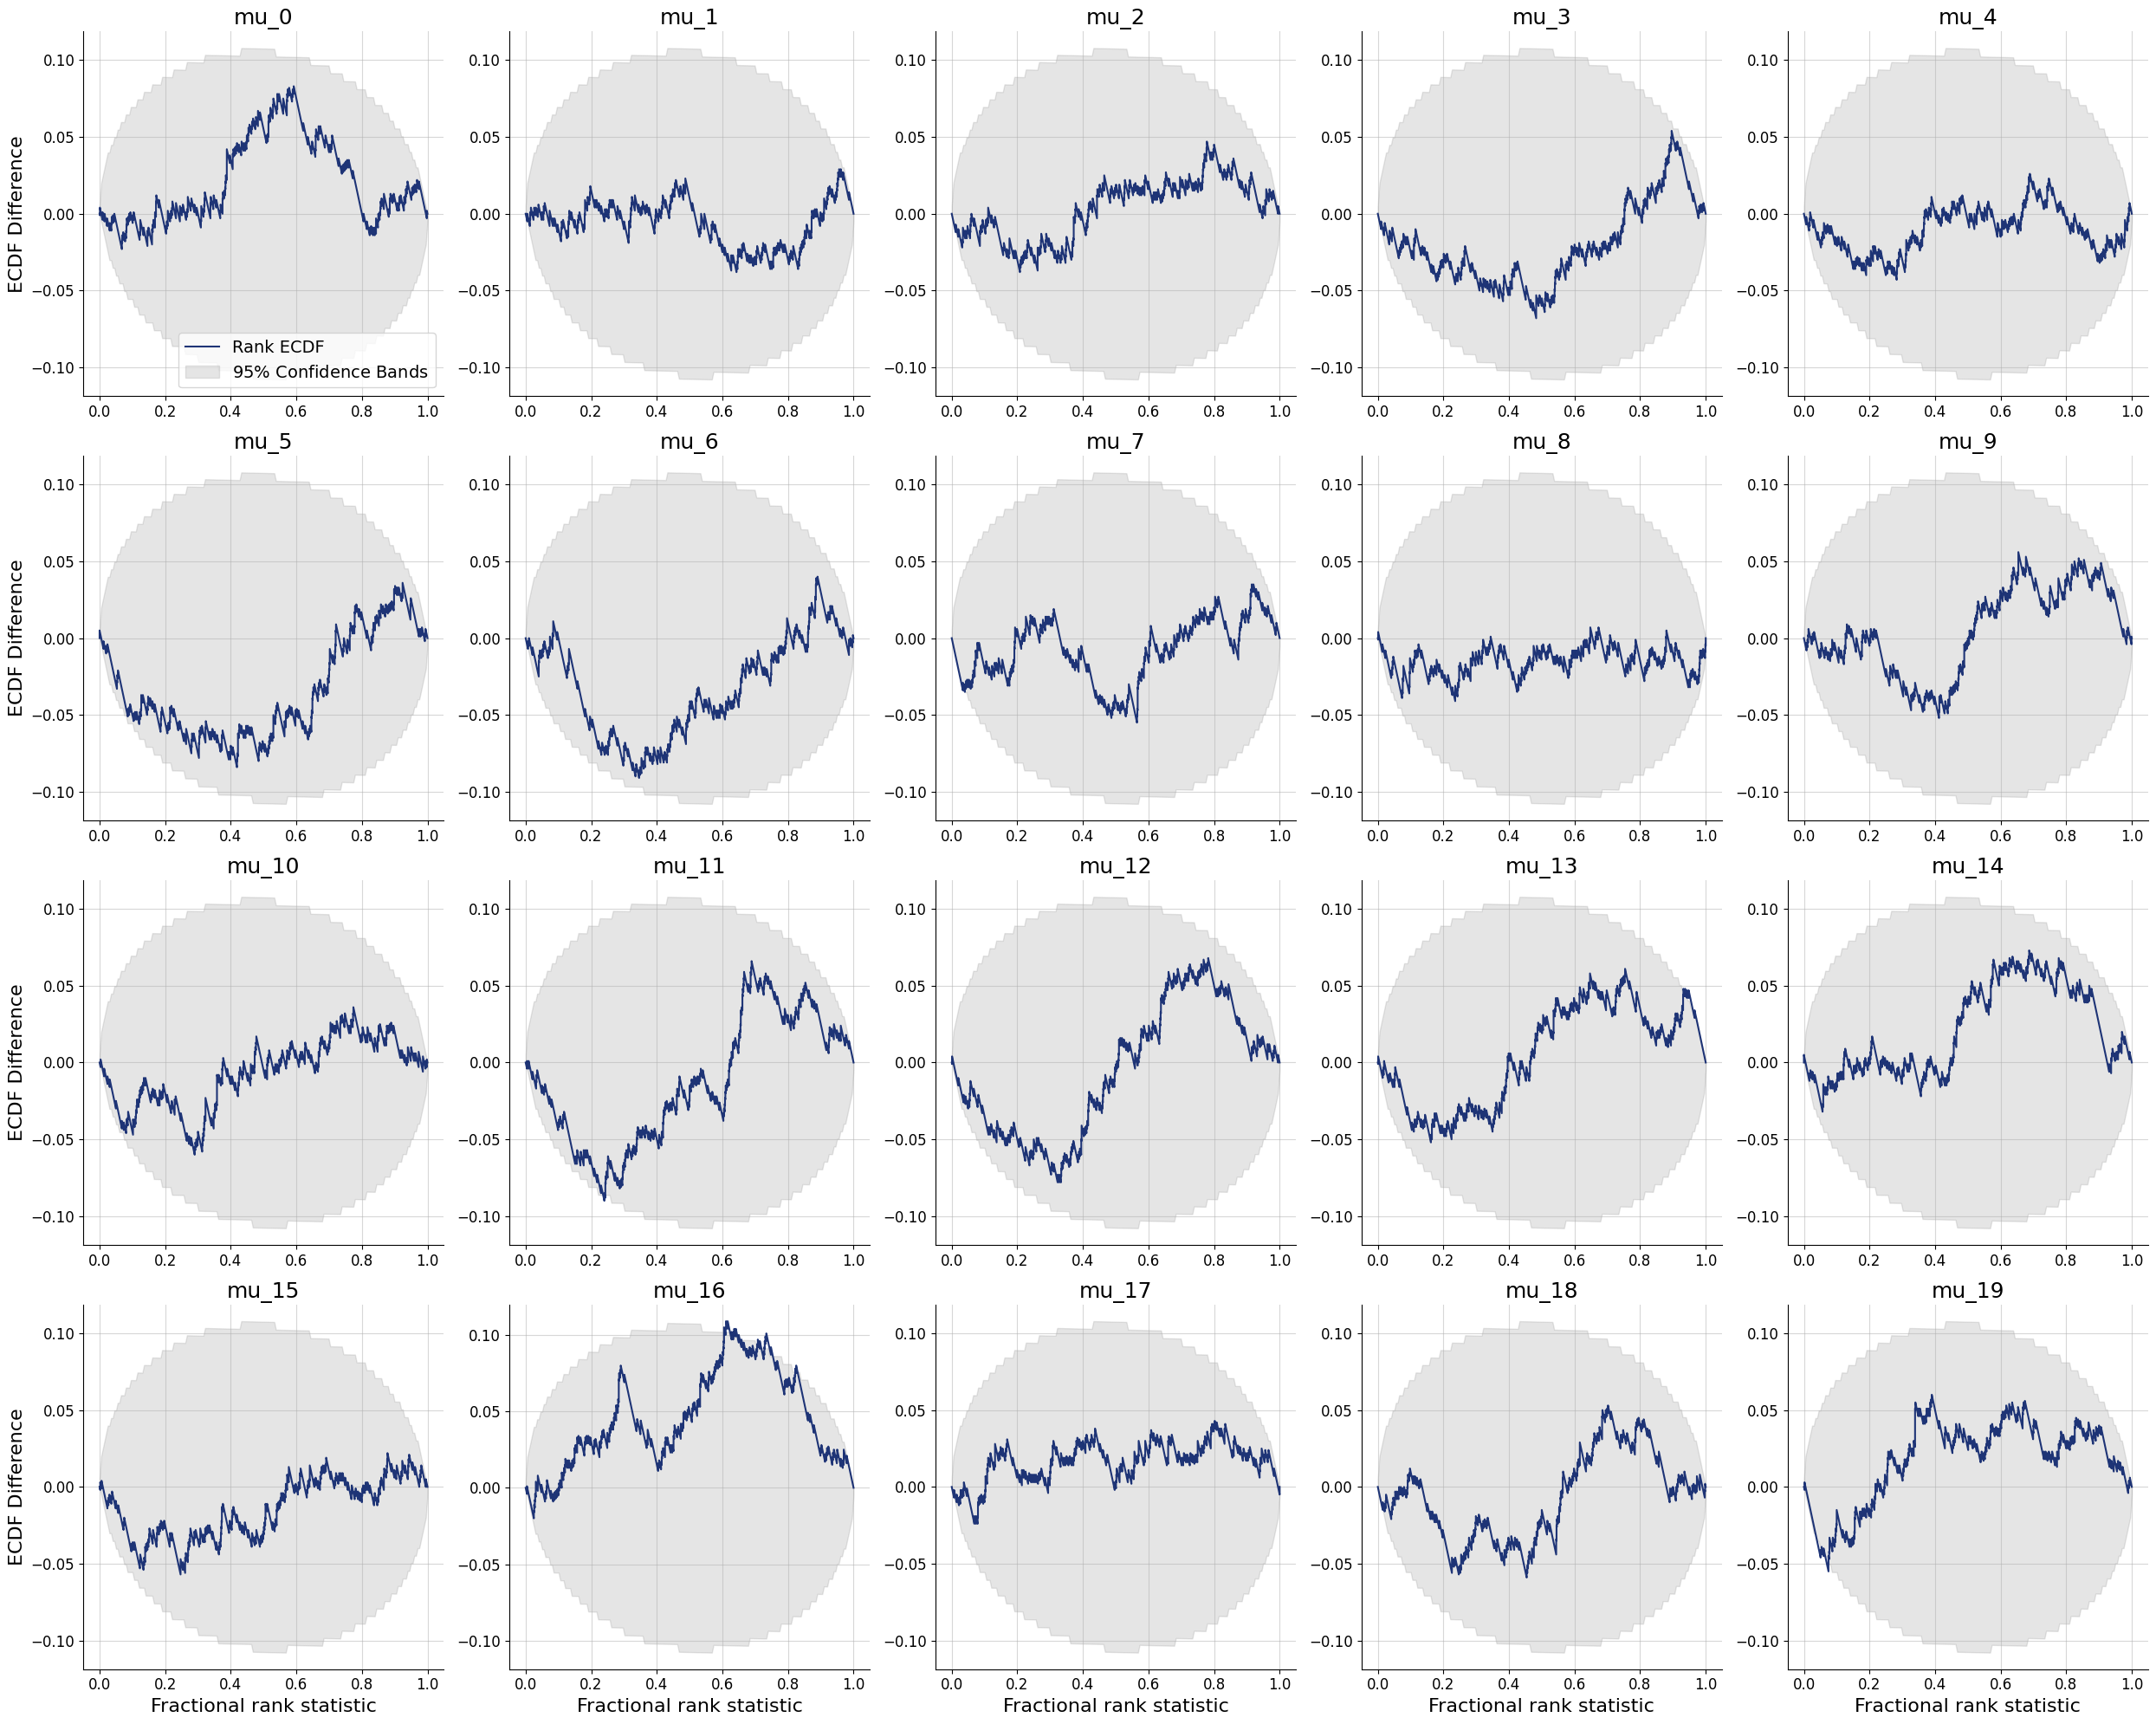

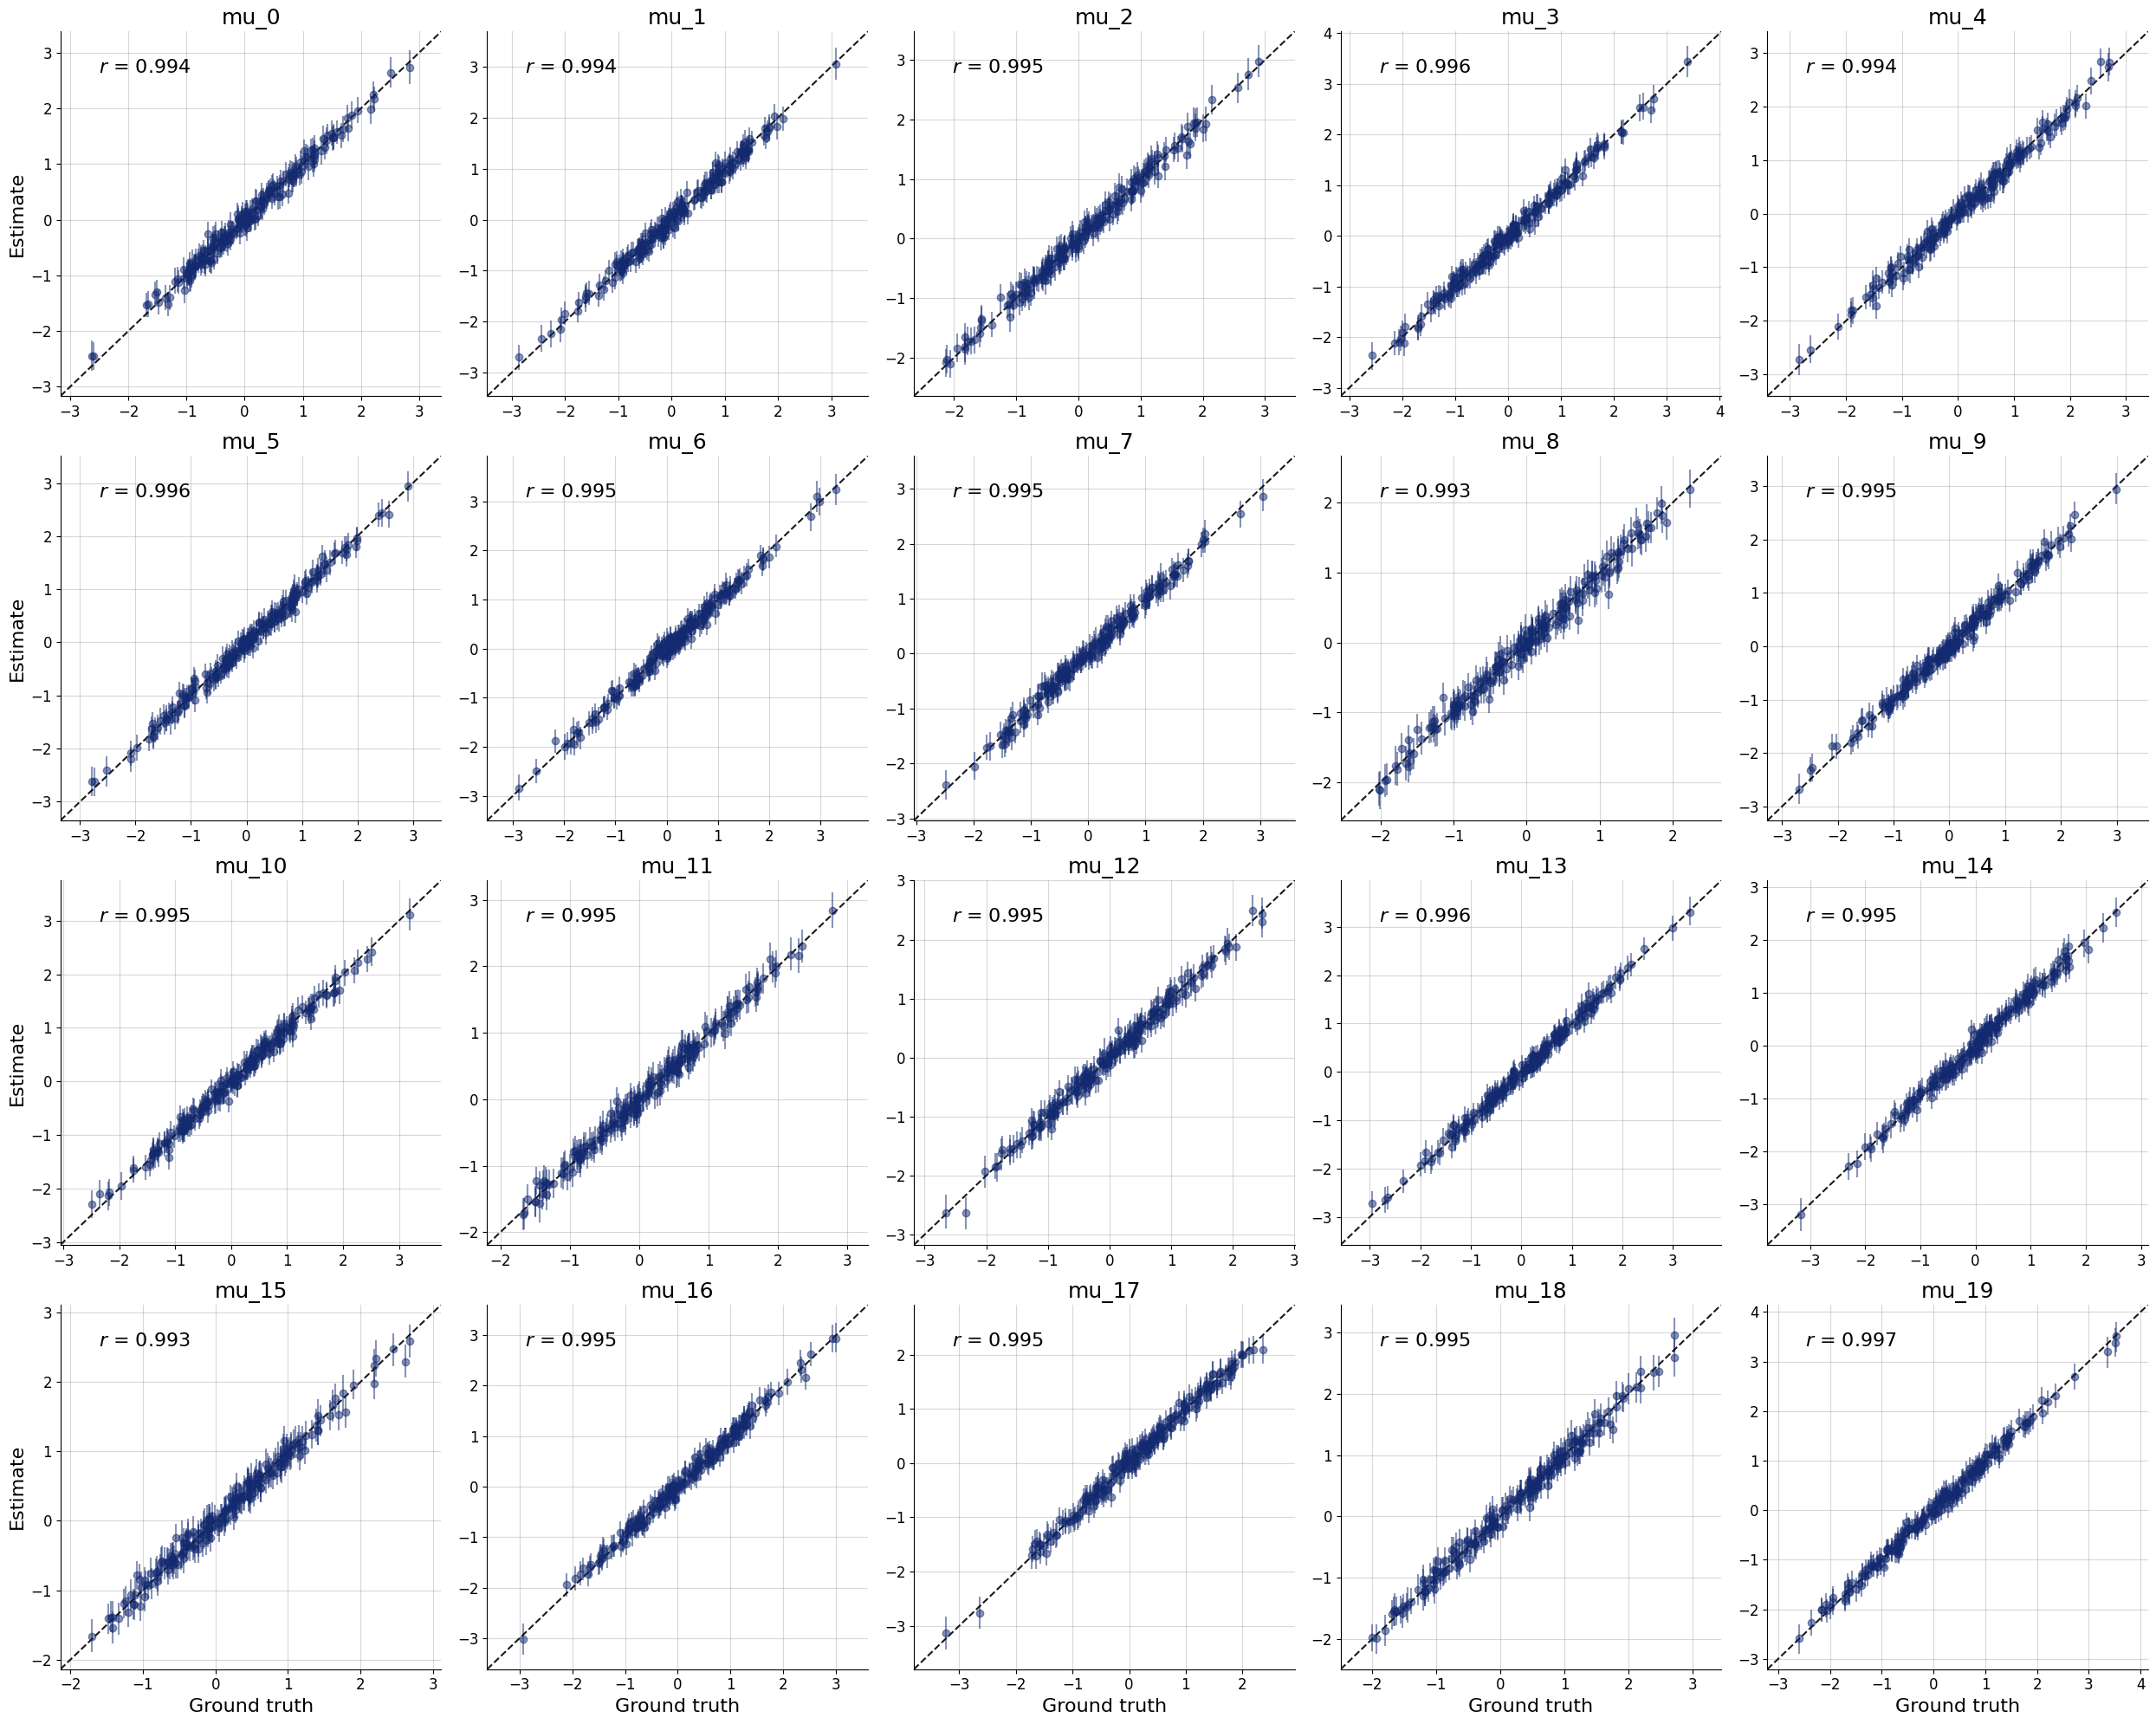

In [25]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [26]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m4_s_20d_100n.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [27]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m4_s_20d_100n.keras"
approximator = keras.saving.load_model(filepath)

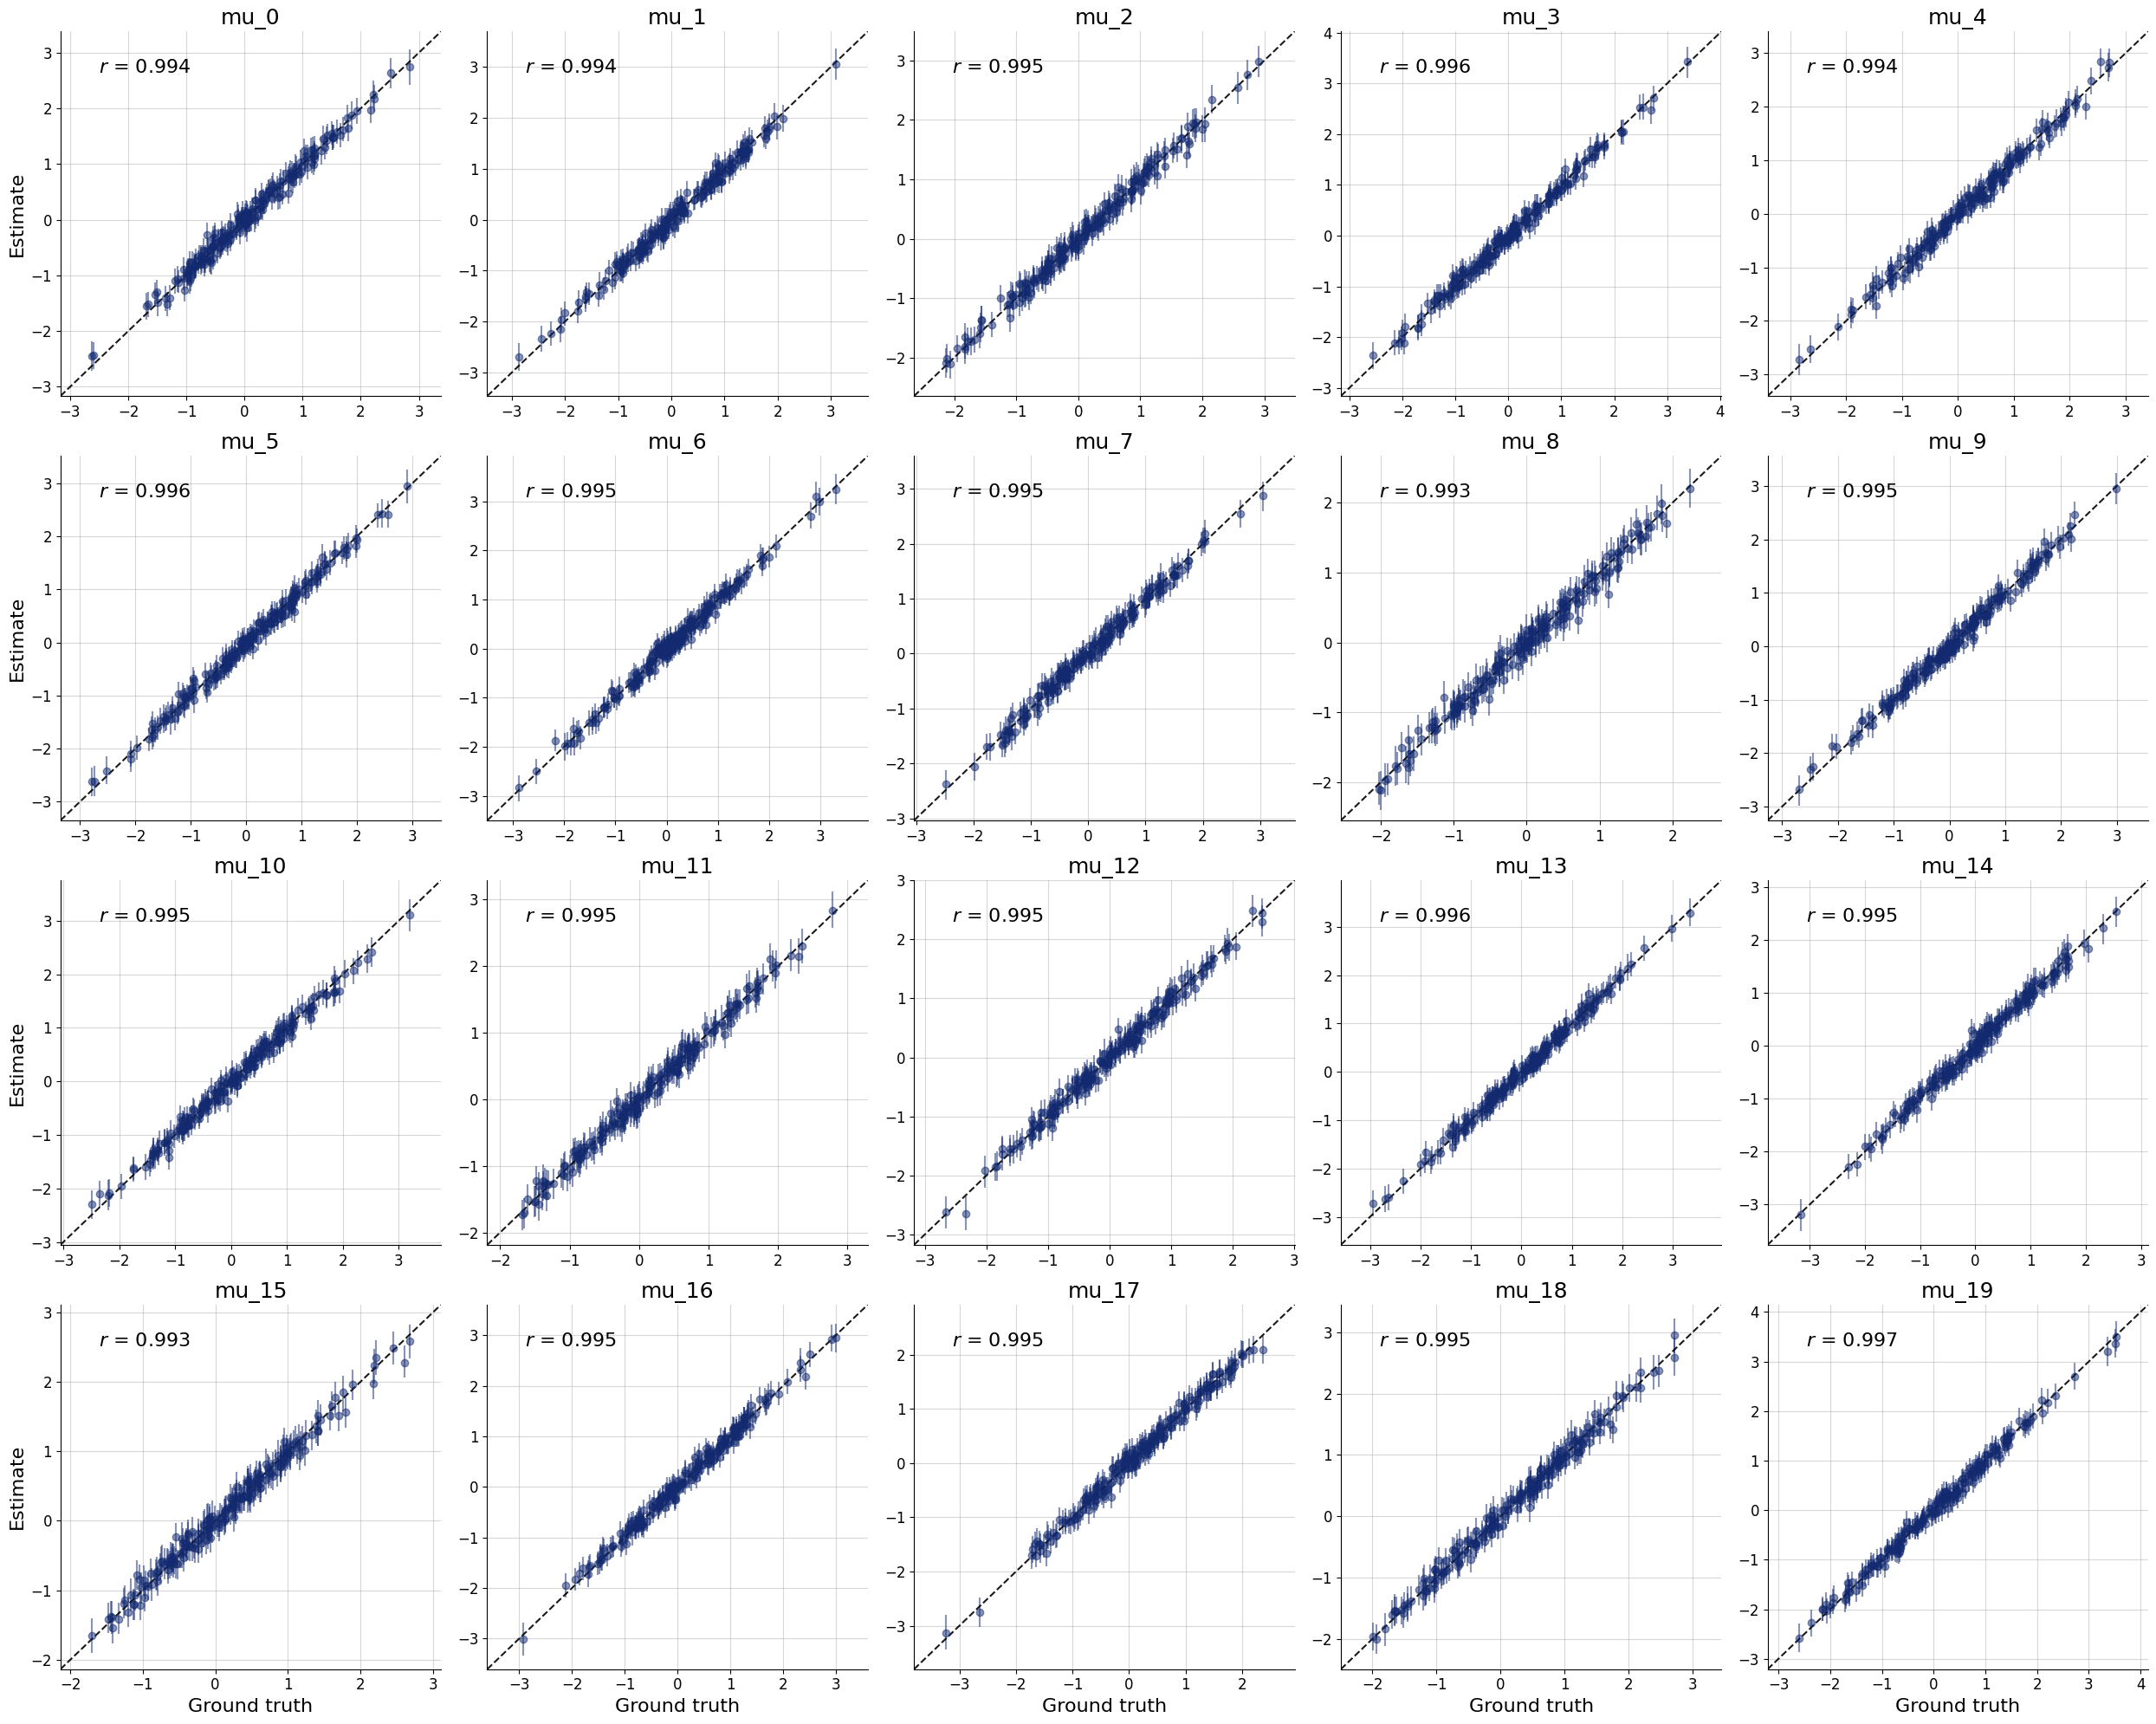

In [28]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)